In [ ]:
#used to handel data ,manimpulate
import numpy as np
import pandas as pd
#used to plot result on graphs
import matplotlib.pyplot as plt

#used to deep learnig tasks
import tensorflow as tf

#preprocessing on data
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

#bild archticture of LSTM model
from keras.models import Sequential
from keras.layers import Embedding , LSTM , Dense , Dropout , BatchNormalization
from keras.regularizers import l2
import time
import pickle
import os

import warnings
warnings.filterwarnings('ignore')



##Read Data


In [ ]:
with open("/next_word_predictor.txt","r" , encoding="utf-8") as file :
  text = file.read()

text

'The sun was shining brightly in the clear blue sky, and a gentle breeze rustled the leaves of the tall trees. People were out enjoying the beautiful weather, some sitting in the park, others taking a leisurely stroll along the riverbank. Children were playing games, and laughter filled the air.\n\nAs the day turned into evening, the temperature started to drop, and the sky transformed into a canvas of vibrant colors. Families gathered for picnics, and the smell of barbecues wafted through the air. It was a perfect day for a picnic by the lake.\n\nIn the distance, you could hear the sound of live music coming from a local band, and people began to gather around the stage to enjoy the performance. The atmosphere was electric, and the music had everyone swaying to the beat.\n\nAs the stars began to twinkle in the night sky, the crowd grew even larger, and the festivities continued well into the night. It was a day filled with joy, laughter, and memories that would last a lifetime.\n\n\nT

##Clean data



In [ ]:
def separate_punc(doc_text):
    #split sentence to words
    words = doc_text.split(" ")
    result = []
#append word with out Punctuations
    for word in words:
        if word not in '\n\n \n\n\n!"-#$%&()--.*+,-/:;<=>?@[\\]^_`{|}~\t\n ':
            result.append(word.lower())

    return result


In [ ]:
text = separate_punc(text)
text

['the',
 'sun',
 'was',
 'shining',
 'brightly',
 'in',
 'the',
 'clear',
 'blue',
 'sky,',
 'and',
 'a',
 'gentle',
 'breeze',
 'rustled',
 'the',
 'leaves',
 'of',
 'the',
 'tall',
 'trees.',
 'people',
 'were',
 'out',
 'enjoying',
 'the',
 'beautiful',
 'weather,',
 'some',
 'sitting',
 'in',
 'the',
 'park,',
 'others',
 'taking',
 'a',
 'leisurely',
 'stroll',
 'along',
 'the',
 'riverbank.',
 'children',
 'were',
 'playing',
 'games,',
 'and',
 'laughter',
 'filled',
 'the',
 'air.\n\nas',
 'the',
 'day',
 'turned',
 'into',
 'evening,',
 'the',
 'temperature',
 'started',
 'to',
 'drop,',
 'and',
 'the',
 'sky',
 'transformed',
 'into',
 'a',
 'canvas',
 'of',
 'vibrant',
 'colors.',
 'families',
 'gathered',
 'for',
 'picnics,',
 'and',
 'the',
 'smell',
 'of',
 'barbecues',
 'wafted',
 'through',
 'the',
 'air.',
 'it',
 'was',
 'a',
 'perfect',
 'day',
 'for',
 'a',
 'picnic',
 'by',
 'the',
 'lake.\n\nin',
 'the',
 'distance,',
 'you',
 'could',
 'hear',
 'the',
 'sound',
 

In [ ]:
#replase word to sentence
clean_data = " ".join(text)
clean_data

'the sun was shining brightly in the clear blue sky, and a gentle breeze rustled the leaves of the tall trees. people were out enjoying the beautiful weather, some sitting in the park, others taking a leisurely stroll along the riverbank. children were playing games, and laughter filled the air.\n\nas the day turned into evening, the temperature started to drop, and the sky transformed into a canvas of vibrant colors. families gathered for picnics, and the smell of barbecues wafted through the air. it was a perfect day for a picnic by the lake.\n\nin the distance, you could hear the sound of live music coming from a local band, and people began to gather around the stage to enjoy the performance. the atmosphere was electric, and the music had everyone swaying to the beat.\n\nas the stars began to twinkle in the night sky, the crowd grew even larger, and the festivities continued well into the night. it was a day filled with joy, laughter, and memories that would last a lifetime.\n\n\nt

##Implementation Tokenizer



In [ ]:
tokenizer = Tokenizer(num_words=None , char_level=False)
tokenizer.fit_on_texts([clean_data])

tokenizer.word_index

{'the': 1,
 'and': 2,
 'a': 3,
 'of': 4,
 'to': 5,
 'i': 6,
 'you': 7,
 'in': 8,
 'is': 9,
 'monica': 10,
 'it': 11,
 'with': 12,
 'ross': 13,
 'that': 14,
 'rachel': 15,
 'for': 16,
 'chandler': 17,
 'this': 18,
 'on': 19,
 'joey': 20,
 'was': 21,
 'oh': 22,
 'phoebe': 23,
 'are': 24,
 'all': 25,
 'as': 26,
 'what': 27,
 'be': 28,
 'like': 29,
 'no': 30,
 "it's": 31,
 "i'm": 32,
 'her': 33,
 'they': 34,
 'just': 35,
 'from': 36,
 'okay': 37,
 'not': 38,
 'so': 39,
 'my': 40,
 'have': 41,
 'me': 42,
 'where': 43,
 'know': 44,
 'she': 45,
 'we': 46,
 'out': 47,
 'well': 48,
 'their': 49,
 'can': 50,
 'at': 51,
 'he': 52,
 'yeah': 53,
 'your': 54,
 'about': 55,
 'but': 56,
 'its': 57,
 'up': 58,
 "don't": 59,
 'text': 60,
 'scene': 61,
 'by': 62,
 'do': 63,
 'an': 64,
 'or': 65,
 'were': 66,
 'there': 67,
 'if': 68,
 'uh': 69,
 'look': 70,
 'life': 71,
 'through': 72,
 'into': 73,
 'him': 74,
 'his': 75,
 "you're": 76,
 'hey': 77,
 'how': 78,
 'right': 79,
 'think': 80,
 'time': 81,
 'no

In [ ]:
print (len(tokenizer.word_index))

4993


##generating input sequences

In [ ]:
input_sequence =[]

for sentence in clean_data.split("\n"):

  tokenized_sentance = tokenizer.texts_to_sequences([sentence])[0]


  for i in range (1 , len(tokenized_sentance)):

    input_sequence.append(tokenized_sentance[:i+1])



print(input_sequence[:20])

[[1, 155], [1, 155, 21], [1, 155, 21, 2368], [1, 155, 21, 2368, 1549], [1, 155, 21, 2368, 1549, 8], [1, 155, 21, 2368, 1549, 8, 1], [1, 155, 21, 2368, 1549, 8, 1, 422], [1, 155, 21, 2368, 1549, 8, 1, 422, 692], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369, 1550], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369, 1550, 2370], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369, 1550, 2370, 1], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369, 1550, 2370, 1, 423], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369, 1550, 2370, 1, 423, 4], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369, 1550, 2370, 1, 423, 4, 1], [1, 155, 21, 2368, 1549, 8, 1, 422, 692, 215, 2, 3, 2369, 1550, 2370, 1, 423, 4, 1, 1142], [1, 155, 21, 2368, 1549, 8, 1, 42

##Finding Maximum Sequence Length

In [ ]:
max_len = max([len(x)for x in input_sequence])
max_len

325

##padded input sequencea


In [ ]:
padded_input_seq = pad_sequences (input_sequence , maxlen = max_len , padding = "pre")

X = padded_input_seq[:, :-1]
y = padded_input_seq[:, -1]

print("X = ",X.shape)
print ("y =" , y.shape)

X =  (26383, 324)
y = (26383,)




```
`# This is formatted as code`
```

##one hot encodding label ![](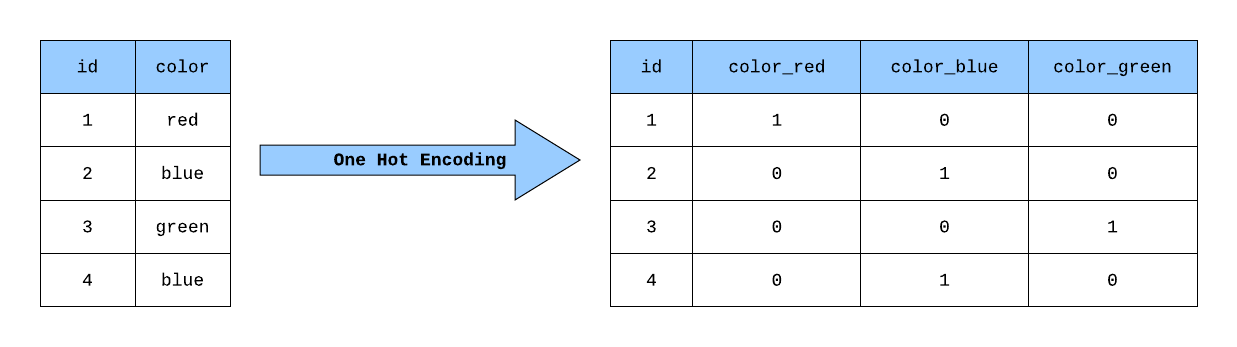)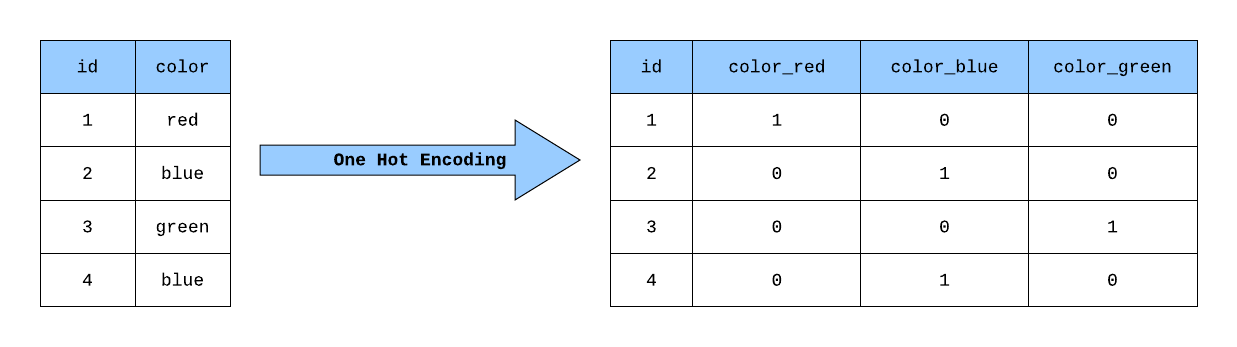

In [ ]:
y = to_categorical(y , num_classes=len(tokenizer.word_index)+ 1)
print(y.shape)

(26383, 4994)


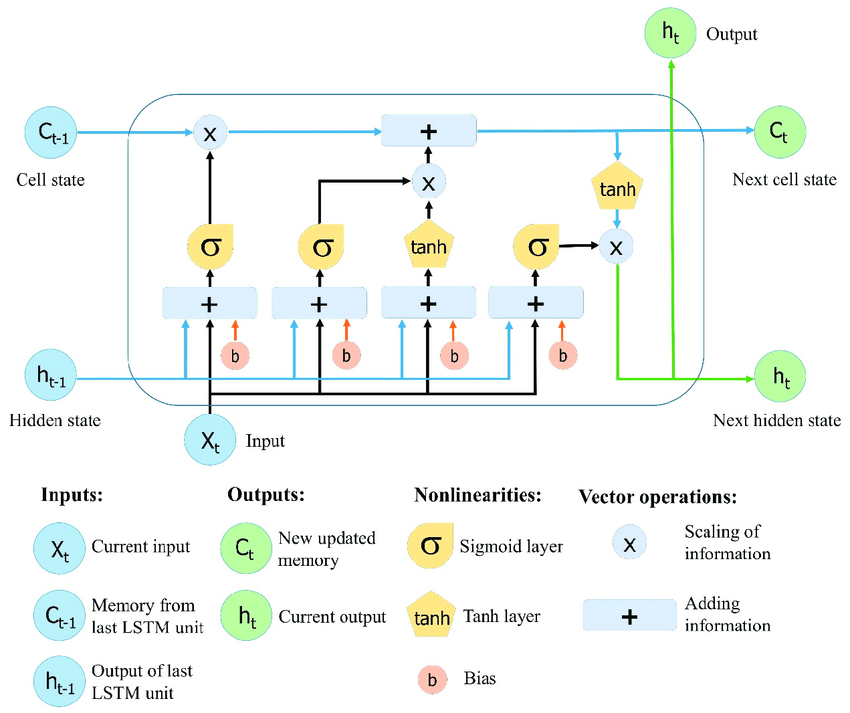

In [ ]:
model=Sequential()
model.add(Embedding(4994 , 100, input_length=324))
model.add(LSTM(150))
model.add(Dense(4994, activation='softmax'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Training


In [ ]:
history = model.fit(X, y, epochs=150)

Epoch 1/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - acc: 0.0374 - loss: 0.0741
Epoch 2/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - acc: 0.0469 - loss: 0.0016
Epoch 3/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - acc: 0.0455 - loss: 0.0016
Epoch 4/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - acc: 0.0476 - loss: 0.0016
Epoch 5/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - acc: 0.0488 - loss: 0.0016
Epoch 6/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - acc: 0.0473 - loss: 0.0016
Epoch 7/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - acc: 0.0525 - loss: 0.0016
Epoch 8/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - acc: 0.0495 - loss: 0.0016
Epoch 9/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - acc: 0.0497 - loss: 0.0016
Epoch 10/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - acc: 0.0478 - loss: 0.0016
Epoch 11/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - acc: 0.0497 - loss: 0.0016
Epoch 12/150
825/825 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - acc: 0.0500 - lo

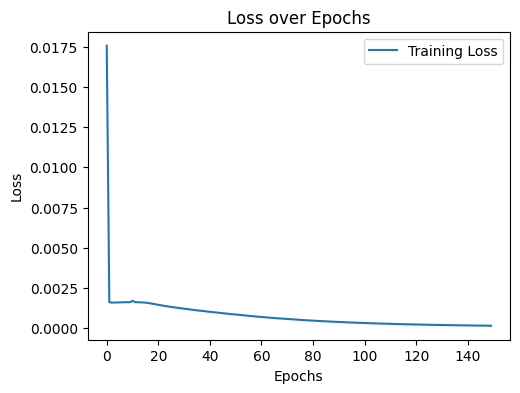

In [ ]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

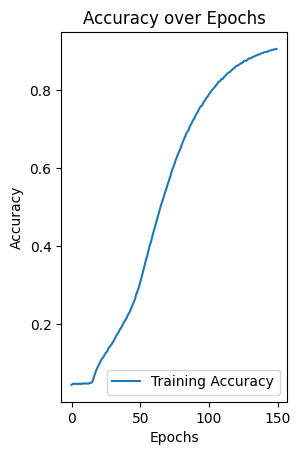

In [ ]:
# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['acc'], label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

##Use model

In [ ]:
text = input("Enter yor word: ")
num_word = input("How many words do you want?")
num_word = int(num_word)

for i in range(num_word):
    # Tokenize the input text
    token_text = tokenizer.texts_to_sequences([text])[0]
    # Pad the tokenized text
    padded_token_text = pad_sequences([token_text], maxlen=324, padding='pre')
    # Predict the next word index
    pos = np.argmax(model.predict(padded_token_text))

    # Retrieve the word corresponding to the predicted index
    for word, index in tokenizer.word_index.items():
        if index == pos:
            # Append the predicted word to the input text
            text = text + " " + word
            print(text)
            # Simulate typing effect with a delay of 1 second
            time.sleep(1)

Enter yor word: The surrounding meadows were adorned with
How many words do you want?10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
The surrounding meadows were adorned with wildflowers
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The surrounding meadows were adorned with wildflowers and
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The surrounding meadows were adorned with wildflowers and the
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The surrounding meadows were adorned with wildflowers and the song
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
The surrounding meadows were adorned with wildflowers and the song of
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
The surrounding meadows were adorned with wildflowers and the song of birds
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
The surrounding meadows were adorned with wildflowers and the song of birds filled
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
The surrounding meadows were adorned with wildflowers and the song of birds filled the
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The surroundi

In [ ]:
model.save('/model/model_next text prediction LSTM model.h5')